# **Pre-Trained Model 2 - MobileNetV2**

MobileNetV2 was selected as the second pretrained architecture for the modelling phase. <br>

### **Why MobileNet?**

MobileNet is a family of CNN architectures designed for efficiency, built around *inverted residuals* and *linear bottlenecks*. These use a structure where the input is first expanded into a higher-dimensional space, processed with depthwise separable convolutions, and then projected back down. This allows the network to learn rich representations while keeping the number of parameters very low.

### **Why V2 specifically?**

MobileNetV2 improves upon the original MobileNet by introducing residual connections between bottleneck layers, which mitigates gradient degradation during training. With approximately 3.4M parameters it is the lightest model in our comparison, making it a strong candidate for deployment-oriented scenarios where **inference speed and memory footprint** matter. In our study, it serves as the **efficiency baseline**, testing whether a leaner architecture can remain competitive with EfficientNetB0 on this task.

#### Dataset-specific considerations:
- **Suitability for dermoscopy**: The depthwise separable convolutions in MobileNetV2 are effective at extracting local texture features relevant to dermoscopic classification, such as colour gradients and structural patterns. Although shallower than EfficientNetB0, the inverted residual blocks still capture sufficient spatial detail at 224×224 resolution;
- **Fine-tuning depth**: Given MobileNetV2's shallower architecture, we unfreeze only the last 20 layers in phase 2 (versus 30 for EfficientNetB0). This is a deliberate choice to avoid destabilising the early depthwise convolution layers, which encode the most generalisable low-level features and are particularly valuable when training data is limited.


### Imports

In [1]:
import tensorflow as tf
#prevent TF from grabbing all GPU memory at once
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
from tensorflow.keras import mixed_precision

# Tell Keras to use float16 for memory, but keep float32 for numeric stability in the loss
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Laptop GPU, compute capability 8.6
Compute dtype: float16
Variable dtype: float32


In [3]:
import os
import sys
import keras.applications
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from keras.applications.efficientnet import preprocess_input


if os.getcwd().endswith('models'):
    os.chdir('..')
    
from utils.utils_model import *
from utils.utils_augmentation import *
from utils.utils_preproc import *

In [4]:
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.applications import MobileNetV2

In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
print("TF built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available to TF:", tf.test.is_gpu_available())  # deprecated but still works

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU available to TF: True


### **Data** Configuration

In [6]:
# Load label mapping first — everything else depends on it
with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

N_CLASSES  = len(label2idx)
BATCH_SIZE = 32

train_df = pd.read_csv('data/augmented_metadata.csv')
val_df   = pd.read_csv('data/val_split.csv')
test_df  = pd.read_csv('data/test_split.csv')

# Normalise column names and encode labels for all splits
for df in [train_df, val_df, test_df]:
    if 'cleaned_path' in df.columns and 'image_path' in df.columns:
        df.drop(columns=['image_path'], inplace=True)
    df.rename(columns={'cleaned_path': 'image_path'}, inplace=True)
    df['dx_encoded'] = df['dx'].map(label2idx).astype(int)

# Build datasets
train_ds = make_dataset(train_df, shuffle=True, repeat=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE
class_weights_dict = make_class_weights(train_df)

In [7]:
print(f"Steps per epoch: {STEPS_PER_EPOCH}")
print(f"Class weights: {class_weights_dict}")

Steps per epoch: 394
Class weights: {0: 1.4493569131832797, 1: 1.2340862422997947, 2: 0.8370473537604457, 3: 2.504166666666667, 4: 0.8727008712487899, 5: 0.42867332382310985, 6: 2.3415584415584414}


### **Model** Configuration

In [8]:
def build_mobilenet_v2():
    """
    Builds a MobileNetV2 model with a frozen pretrained base and a
    custom classifier head. The head architecture is identical to the 
    other models so results remain directly comparable.
    """
    # Load MobileNetV2 instead of DenseNet
    base = keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling=None
    )
    # Frozen base for Phase 1
    base.trainable = False

    inputs  = Input(shape=(224, 224, 3))
    # Pass inputs through the frozen base
    x = base(inputs, training=False)

    # Identical custom head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(N_CLASSES)(x)
    
    # Updated model name
    return keras.Model(inputs, outputs, name="mobilenet_v2")

Model: "mobilenet_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 batch_normalization_1 (Batc  (None, 256)             

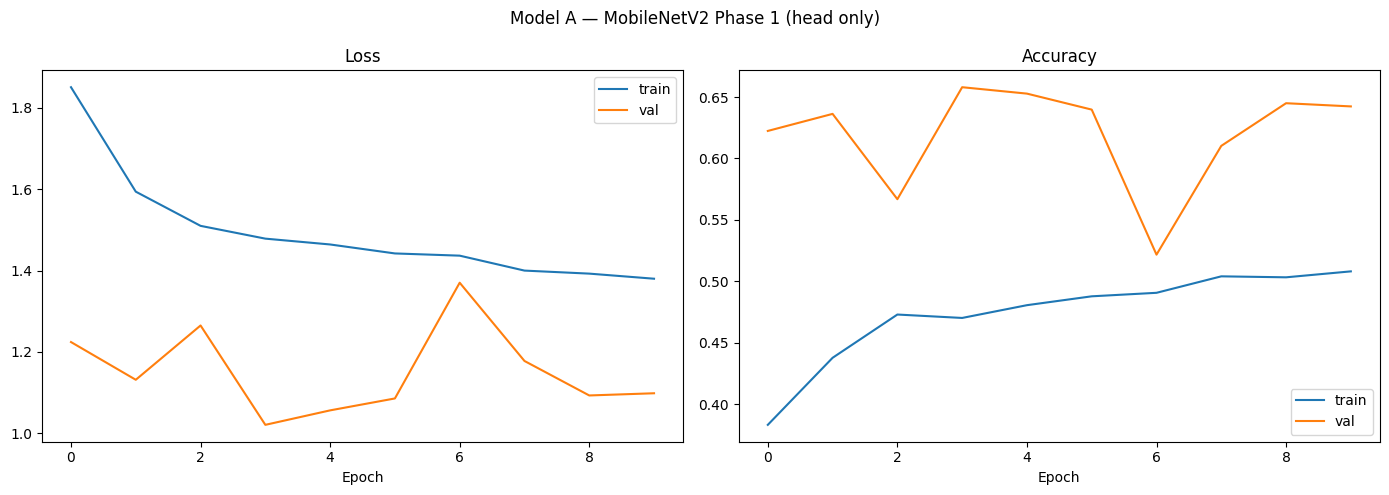

In [10]:
# phase 1: head only
model_pt1 = build_mobilenet_v2() # Model Pre-Trained 1
model_pt1.summary()

model_pt1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)]
)

my_callbacks = get_callbacks(
    checkpoint_path="checkpoints/model_MN_phase1.weights.h5",
    model=model_pt1,      # <--- Pass your model here
    max_diff=0.15,        # <--- Your 15% limit
    patience_es=6, 
    patience_lr=3
)

history1_pt1 = model_pt1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

plot_history(history1_pt1, "Model A — MobileNetV2 Phase 1 (head only)")

In [11]:
# Create a fresh, untrained model using your blueprint
model_pt2 = build_mobilenet_v2()

In [12]:
# Load the Phase 1 weights from the hard drive
model_pt2.load_weights("checkpoints/model_MN_phase1.weights.h5")
print("Phase 1 weights loaded successfully!")

Phase 1 weights loaded successfully!


Epoch 1/50
394/394 [==============================] - ETA: 0s - loss: 1.4188 - accuracy: 0.4969 - balanced_accuracy: 0.4475
Epoch 1: val_loss improved from inf to 0.96345, saving model to checkpoints\model_MN_phase2.weights.h5
394/394 [==============================] - 83s 108ms/step - loss: 1.4188 - accuracy: 0.4969 - balanced_accuracy: 0.4475 - val_loss: 0.9634 - val_accuracy: 0.6554 - val_balanced_accuracy: 0.3805 - lr: 1.0000e-05
Epoch 2/50
394/394 [==============================] - ETA: 0s - loss: 1.3097 - accuracy: 0.5312 - balanced_accuracy: 0.4993
Epoch 2: val_loss did not improve from 0.96345
394/394 [==============================] - 38s 95ms/step - loss: 1.3097 - accuracy: 0.5312 - balanced_accuracy: 0.4993 - val_loss: 1.0296 - val_accuracy: 0.6328 - val_balanced_accuracy: 0.4470 - lr: 1.0000e-05
Epoch 3/50
394/394 [==============================] - ETA: 0s - loss: 1.2363 - accuracy: 0.5477 - balanced_accuracy: 0.5184
Epoch 3: val_loss did not improve from 0.96345
394/394 [=

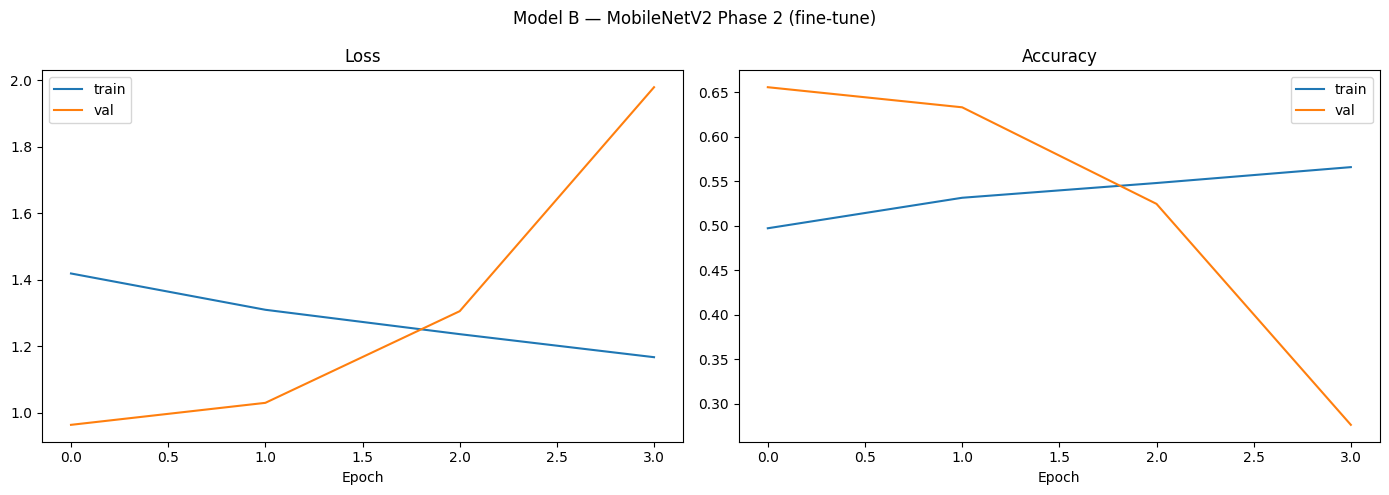


  Model B — MobileNetV2 — classification report
              precision    recall  f1-score   support

       akiec       0.31      0.62      0.41        29
         bcc       0.33      0.37      0.35        65
         bkl       0.36      0.36      0.36       109
          df       0.14      0.25      0.18         8
         mel       0.30      0.61      0.40       127
          nv       0.99      0.23      0.37       778
        vasc       0.02      0.90      0.04        10

    accuracy                           0.31      1126
   macro avg       0.35      0.48      0.30      1126
weighted avg       0.78      0.31      0.37      1126

  *** Melanoma recall: 0.606 ***  (clinical priority metric)


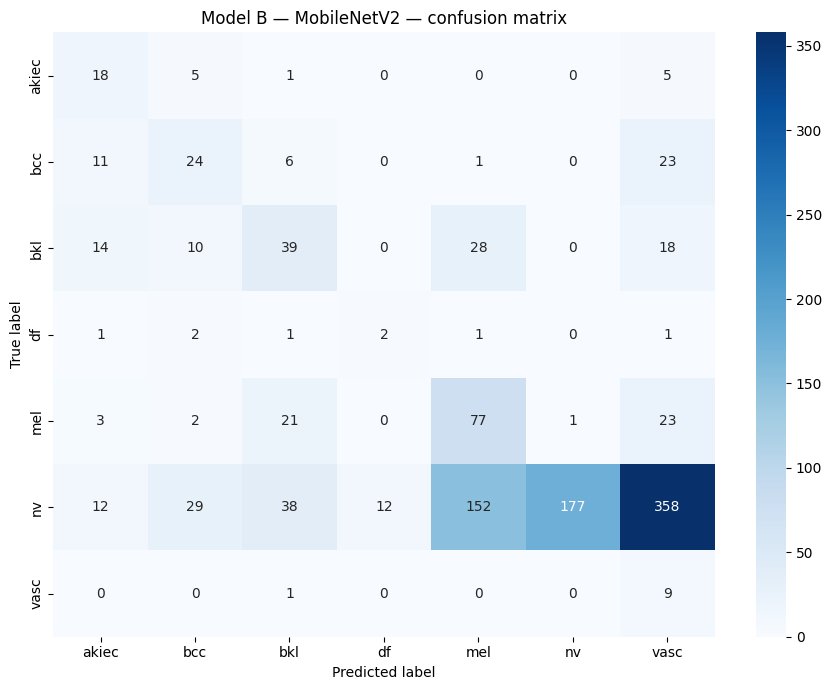


  Macro AUC-ROC: 0.8644


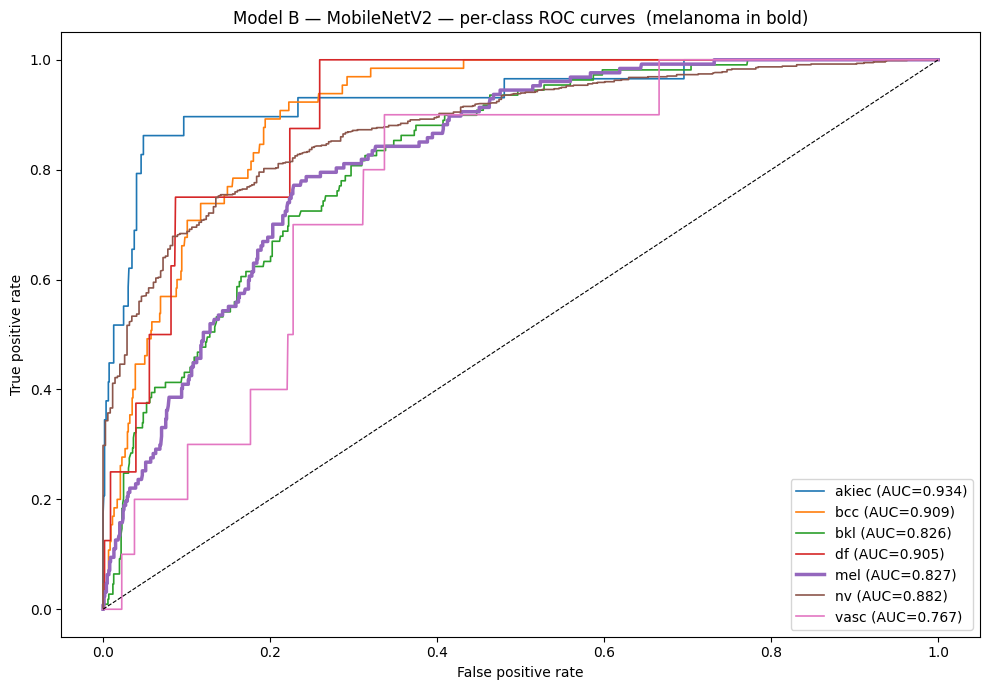

In [14]:
# Phase 2: Fine-tune top layers
base_b = model_pt2.get_layer('mobilenetv2_1.00_224')
base_b.trainable = True

for layer in base_b.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

model_pt2.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)])

my_callbacks = get_callbacks(
    checkpoint_path="checkpoints/model_MN_phase2.weights.h5",
    model=model_pt2,    
    max_diff=0.15,       
    patience_es=10, 
    patience_lr=5
)

history2_b0 = model_pt2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

plot_history(history2_b0, "Model B — MobileNetV2 Phase 2 (fine-tune)")
results_b = evaluate_model(model_pt2, test_ds, label2idx, "Model B — MobileNetV2")